<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_SPT0346_52.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy SPT0346-52**

"*The Formation of a Primeval Hyperstarburst Galaxy at z~6*" refers to a galaxy.
* In astronomy, a "starburst galaxy" is a galaxy undergoing an exceptionally high rate of star formation, often triggered by interactions or mergers with other galaxies.
* The term "primeval" here suggests that this galaxy is very young or in an early stage of formation.
* The redshift $ z \approx 6 $ indicates that this galaxy formed in the very early universe, around 12.8 billion years ago.
* Such hyperstarburst galaxies are among the first massive structures to form, and they provide clues about galaxy formation and evolution in the early universe.
* https://jwstfeed.com/PostView/FeedPost?ci=1674172800_jw01864-o002_t001_miri_f770w
* https://www.stsci.edu/jwst/phase2-public/1864.pdf
* https://ui.adsabs.harvard.edu/abs/2021jwst.prop.1864P/abstract

In [17]:
!pip install astropy photutils astroquery lightkurve -q

from astropy import units as u
from astroquery.ipac.irsa import Irsa
import lightkurve as lk
from astroquery.vizier import Vizier
from astropy.coordinates import Angle
from astroquery.splatalogue import Splatalogue
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline

**Display possible datasets**

In [18]:
# Access infrared data from JWS instruments
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='JWST',           # Specific to JWST
    instrument_name=['NIRCam', 'MIRI', 'NIRSpec', 'NIRISS', 'FGS']
)

# Display the results
print(obs_table)

 intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
----------- -------------- --------------- --------------- ... ------ ------ --------- ---------
    science           JWST         CALJWST         NIRSPEC ...  False    nan 107458509 204963674
    science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479
calibration           JWST         CALJWST             FGS ...  False    nan  71739127 294621945
calibration           JWST         CALJWST             FGS ...  False    nan  78110357 317255586
calibration           JWST         CALJWST             FGS ...  False    nan  71774526 317392654
calibration           JWST         CALJWST             FGS ...  False    nan  71752546 317392663
calibration           JWST         CALJWST             FGS ...  False    nan  71774896 317557360
calibration           JWST         CALJWST             FGS ...  False    nan  71775531 317557535
calibration           JWST    

In [19]:
# Assuming you've selected specific observations (first one for this example)
data = Observations.get_product_list(obs_table[0])

In [20]:
# Instead of downloading, just count unique products
unique_products = len(set(data['productFilename']))

# Print the count of unique products
print(f"Number of unique products: {unique_products}")

Number of unique products: 803


In [21]:
# Show the available data products
print(data)

  obsID   obs_collection dataproduct_type ... dataRights calib_level   filters   
--------- -------------- ---------------- ... ---------- ----------- ------------
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
      ...       

In [ ]:
# Download all data
# Observations.download_products(data)

In [22]:
# Select the first few products to download (e.g., first 5 products)
subset = data[:5]  # Adjust the number as needed

# Download the selected data products
Observations.download_products(subset)

INFO:astroquery:Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits with expected size 1284480.


INFO: Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits with expected size 1284480. [astroquery.query]


INFO:astroquery:Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233957_cal.fits with expected size 1284480.


INFO: Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233957_cal.fits with expected size 1284480. [astroquery.query]


INFO:astroquery:Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233914_cal.fits with expected size 106560.


...

INFO:astroquery:Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233959_cal.fits with expected size 106560.


INFO: Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233959_cal.fits with expected size 106560. [astroquery.query]


INFO:astroquery:Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-fg_2022285235710_cal.fits with expected size 15618240.


INFO: Found cached file ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-fg_2022285235710_cal.fits with expected size 15618240. [astroquery.query]


Local Path,Status,Message,URL
str95,str8,object,object
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233957_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233914_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233959_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-fg_2022285235710_cal.fits,COMPLETE,None,None


In [23]:
# Filter table by column value, based on specific criteria, e.g. only observations using NIRCam
nircam_obs = obs_table[obs_table['instrument_name'] == 'MIRI']
print(nircam_obs)

intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
---------- -------------- --------------- --------------- ... ------ ------ --------- ---------
   science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479


**Load Data**

In [67]:
# Specify the path to the FITS file
fits_file = './mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits'

# Open the FITS file
hdul = fits.open(fits_file)

**Inspect Data Details**

In [68]:
# Print all file information
hdul.info()

Filename: ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   ()      
  1  SCI           1 ImageHDU        56   (128, 128, 6)   float32   
  2  ERR           1 ImageHDU        10   (128, 128, 6)   float32   
  3  DQ            1 ImageHDU        11   (128, 128)   int32 (rescales to uint32)   
  4  ASDF          1 BinTableHDU     11   1R x 1C   [398172B]   


In [44]:
# Access the primary hdul[1] data (if available)
primary_data = hdul[1].data
print(primary_data)  # Will print the data array if it exists (might be large)

[[[  8.142536  -13.936555   22.285309  ...  21.676697   -8.194669
    32.556076 ]
  [-41.560703   13.512048    2.7258801 ...  32.967033   -5.3306823
    21.778505 ]
  [-35.964264   35.62946   -10.948616  ...  41.67142    41.38174
    40.652355 ]
  ...
  [ -5.4767723   2.7370875   0.        ...  35.735516   63.71622
    13.625507 ]
  [  2.7272546  27.818024   27.30424   ...  13.623696   61.141552
    37.7346   ]
  [  5.4352098  -2.7320817 -27.677563  ...  18.881338   49.100853
   -16.51829  ]]

 [[-29.855965  -44.596973  -22.285309  ...  24.386284    0.
    -5.4260125]
  [ -8.31214    21.619276  -24.53292   ...  60.43956    50.641483
    65.33552  ]
  [-16.59889   -49.333096  -32.845848  ...   8.334284    2.7587824
    48.782825 ]
  ...
  [ -8.215159  -10.94835    25.392002  ...  30.237743   47.094597
    10.900405 ]
  [-10.9090185  13.909012  -40.95636   ... -13.623696   -2.7791615
    10.781313 ]
  [  5.4352098 -57.373722   -2.7677562 ...  -8.092002    8.1834755
    30.28353  ]]

 [[ 

In [42]:
# Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data

# Display the header to learn more about the file
print(primary_hdu.header)

print(repr(hdul[1].header))  # Science data HDU header

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2022-10-13T06:07:44.279' / UTC date file created                     ORIGIN  = 'STSCI   '           / Organization responsible for creating file     TIMESYS = 'UTC     '           / principal time system for time-related keywordsTIMEUNIT= 's       '           / Default unit applicable to all time values     FILENAME= 'jw01864003001_gs-acq1_2022285233912_cal.fits' / Name of the file     SDP_VER = '2022_3a '           / Data processing software version number        PRD_VER = 'PRDOPSSOC-058'      / S&OC PRD version number used in data processingOSS_VER = '008.004.014.000'    / Observatory Scheduling Software (OSS) version nCAL_VER = '1.7.2   '           / Calibra

Metadata in `hdul[1]`:

1. **Data Dimensions**:
   - `NAXIS1` and `NAXIS2` values are `128`, meaning each 2D image slice is a 128x128 pixel array.
   - `NAXIS3` is `6`, indicating six layers or frames along the third dimension. Each slice represents a "snapshot" or layer within the same field of view, potentially captured over time or at different wavelengths.

2. **Data Units**:
   - `BUNIT = 'DN/s'` means that the data values are in "Data Numbers per second." This is a common format for raw astronomical data, representing the rate of photon detection by the JWST’s sensors.

3. **WCS (World Coordinate System)**:
   - `RADESYS = 'ICRS'` and the coordinate types `CTYPE1 = 'RA---TAN'` and `CTYPE2 = 'DEC--TAN'` suggest that the data is aligned with the International Celestial Reference System, using Right Ascension (RA) and Declination (Dec) as coordinates. This allows for mapping the data to precise positions in the sky.
   - `CRVAL1` and `CRVAL2` provide the RA and Dec values at the reference pixel, centering the field of view at approximately (RA, Dec) = (56.66°, -52.18°).

4. **Ephemeris Information**:
   - JWST’s position and velocity vectors (e.g., `JWST_X`, `JWST_Y`, `JWST_Z`) indicate where JWST was relative to the Solar System barycenter and Earth at the time of observation, which can be useful for precise astrometry or when considering parallax effects.

Interpreting the Image

Each slice likely captures light from a specific region in space, possibly an object or a section of the sky. The variations in color represent the intensity of detected light, where the color scale (`plasma` colormap) is mapped to the values in Data Numbers per second (DN/s).

Since you have six layers in the data, it’s possible they represent different wavelengths or times. Exploring each slice (as you did with the `2x5` grid approach) can reveal variations between the frames, possibly showing how a celestial feature changes across the layers (e.g., different spectral lines or time variations).

In [45]:
# Access the primary hdul[0] data (if available)
print(hdul[0].data)  # Will print the data array if it exists (might be large)

None


In [ ]:
print(repr(hdul[0].header))  # Primary HDU header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2022-10-13T06:07:44.279' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01864003001_gs-acq1_2022285233912_cal.fits' / Name of the file     
SDP_VER = '2022_3a '           / Data processing software version number        
PRD_VER = 'PRDOPSSOC-058'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.014.000'    / Observatory Scheduling Software (OSS) version n
CAL_VER = '1.7.2   '        

The header information in `hdul[0]` provides extensive metadata about the observational and calibration context for the James Webb Space Telescope (JWST) data. Here's a breakdown of the key fields:

General Information
- **SIMPLE** and **EXTEND**: Indicate that the file conforms to the FITS standard and allows extensions.
- **BITPIX = 8**: Specifies the data type of the primary HDU (header and data unit), though this primary HDU doesn't contain image data (`NAXIS = 0`).
- **DATE**: File creation timestamp.
- **ORIGIN**: The institution responsible for the file's creation (`STSCI`, the Space Telescope Science Institute).
- **TELESCOP = JWST**: Specifies the telescope that acquired the data, the James Webb Space Telescope.
- **TIMESYS = 'UTC'** and **TIMEUNIT = 's'**: Define the time system and units, ensuring time values are in UTC and seconds.

Program and Observation Details
- **TITLE**: Observational program title: "The Formation of a Primeval Hyperstarburst Galaxy at z~6," indicating the scientific goal.
- **PI_NAME**: Principal Investigator's name, `Phadke, Kedar A`.
- **CATEGORY** and **SCICAT**: The proposal and science category (e.g., galaxies), providing context for the observation.
- **OBS_ID** and **VISIT_ID**: Identifiers for the observation and visit, which are helpful for tracing data through JWST's archives.
- **DATE-OBS**, **TIME-OBS**, **DATE-BEG**, **DATE-END**: Start and end timestamps of the observation.

Visit Information
- **VISITYPE**: Type of visit, indicating this is a targeted, fixed observation.
- **ENG_QUAL** and **VISITSTA**: Quality indicators showing the visit's success.
- **VSTSTART** and **VISITEND**: Start and end timestamps of the visit.
- **NEXPOSUR**: Planned number of exposures within the visit.

Instrument Configuration
- **INSTRUME = FGS** and **DETECTOR = GUIDER2**: The instrument used (Fine Guidance Sensor) and the specific detector (Guider 2).
- **EXP_TYPE = FGS_ACQ1**: Specifies that this data comes from an acquisition observation, typically used for guiding purposes rather than scientific imaging.

Exposure Parameters
- **READPATT = 'ACQ1'**: The readout pattern used for data acquisition.
- **NINTS = 6** and **NGROUPS = 2**: Number of integrations and groups within the exposure, providing insight into the readout cadence.
- **DURATION = 12.39 s**: Total duration of the exposure.
- **TFRAME, TGROUP, EFFINTTM**: Describe frame timing, group timing, and effective integration time.

Subarray Information
- **SUBARRAY = '128X128'**: Indicates a 128x128 pixel subarray was used, relevant when dealing with large arrays on detectors to focus on a smaller region.
- **SUBSTRT1, SUBSTRT2**: Starting pixels in the x and y directions for the subarray.

Guide Star Information
- **GS_ORDER**: Guide star index.
- **GS_RA** and **GS_DEC**: RA and Dec of the guide star, critical for orienting the telescope.
- **GS_MAG**: Guide star magnitude, which provides an idea of its brightness.

Calibration and Reference Files
- **CRDS_VER** and **CRDS_CTX**: Indicate the version of the Calibration Reference Data System (CRDS) and the context file used, which help identify the calibration pipeline configuration.
- **R_FLAT, R_MASK, etc.**: Names of various reference files (e.g., flat-field and mask files) used for calibration.

Calibration Steps
- **S_DQINIT**, **S_FLAT**, **S_GUICDS**: Indicate that certain calibration steps, like Data Quality Initialization and Flat Field Correction, are complete.

Summary
This header reveals that this data file primarily serves a guidance function for JWST, rather than scientific imaging. The information here documents the settings and context for the observation, guiding the telescope using a specific guide star and tracking its precise positioning.

In [49]:
print(hdul[4].data)  # Will print the data array if it exists (might be large)

[([ 35,  65,  83, ..., 134, 124,  61],)]


In the FITS file, `hdul[1]`, `hdul[2]`, and `hdul[3]` are each `ImageHDU` extensions, meaning they each contain image data arrays. Here’s a breakdown of what each of these extensions typically represents:

1. **`hdul[1]` (SCI)**:
   - **Label**: `SCI` (Science Data)
   - **Dimensions**: `(128, 128, 6)`, meaning it has 6 layers of 128x128 images.
   - **Data Type**: `float32`.
   - **Description**: This is the main scientific data. Each layer in the third dimension likely represents an individual frame or exposure, capturing the target object(s) in different observations or potentially at different wavelengths.

2. **`hdul[2]` (ERR)**:
   - **Label**: `ERR` (Error Data)
   - **Dimensions**: `(128, 128, 6)`, the same shape as `SCI`.
   - **Data Type**: `float32`.
   - **Description**: This extension contains the estimated uncertainties or error values associated with each pixel in the `SCI` data. Each corresponding pixel in `ERR` provides the uncertainty for the value at the same pixel location in the `SCI` data. This is useful for statistical analysis and understanding the reliability of the measurements in the science data.

3. **`hdul[3]` (DQ)**:
   - **Label**: `DQ` (Data Quality)
   - **Dimensions**: `(128, 128)`, a single 2D image with no layers.
   - **Data Type**: `int32` (rescaled to `uint32`).
   - **Description**: This is a data quality (DQ) map. Each pixel in this map represents flags or codes indicating specific issues or characteristics at that pixel location. For instance, a pixel might be flagged if it is saturated, if it contains a cosmic ray hit, or if it falls outside the field of view. These flags help in filtering out or correcting bad data when processing the science data in `SCI`.

Summary
- **`SCI`** (hdul[1]) is the primary scientific observation data.
- **`ERR`** (hdul[2]) represents the uncertainties in the `SCI` data.
- **`DQ`** (hdul[3]) provides quality flags for each pixel in `SCI`, helping identify problematic pixels.

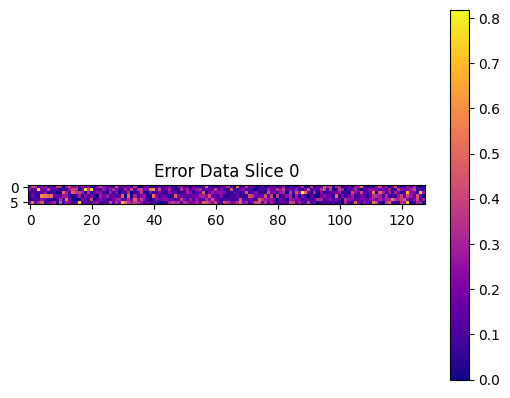

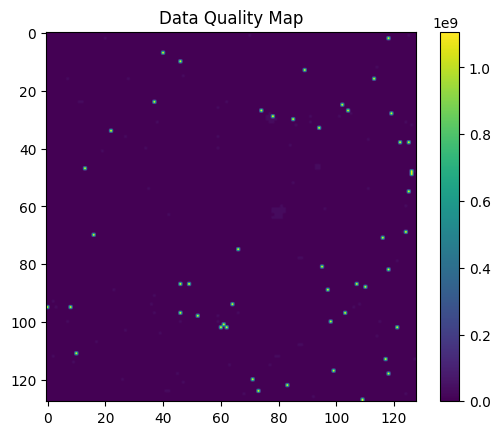

In [74]:
# Plot a slice from ERR and view DQ to visualize each extension individually
# Result gives insight into uncertainties and quality flags associated with science data

# Display a slice from ERR (error) data, e.g., the first slice
plt.imshow(hdul[2].data[:, :, 0], cmap='plasma')
plt.colorbar()
plt.title("Error Data Slice 0")
plt.show()

# Display the DQ (data quality) map
plt.imshow(hdul[3].data, cmap='viridis')
plt.colorbar()
plt.title("Data Quality Map")
plt.show()

**Visualize Data**

In [69]:
# Print all file information
hdul.info()

Filename: ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   ()      
  1  SCI           1 ImageHDU        56   (128, 128, 6)   float32   
  2  ERR           1 ImageHDU        10   (128, 128, 6)   float32   
  3  DQ            1 ImageHDU        11   (128, 128)   int32 (rescales to uint32)   
  4  ASDF          1 BinTableHDU     11   1R x 1C   [398172B]   


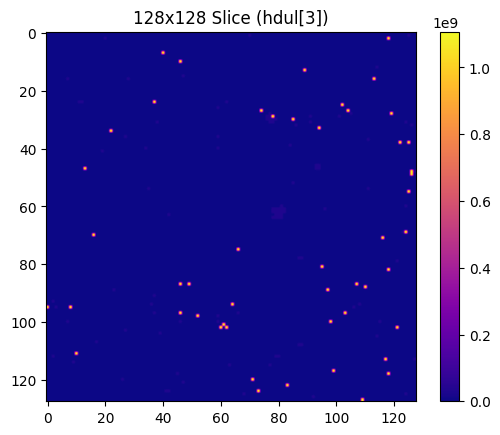

In [70]:
# Display hdul[3].data
plt.imshow(hdul[3].data[:, :], cmap='plasma', aspect='equal')
plt.colorbar()
plt.title("128x128 Slice (hdul[3])")
plt.show()

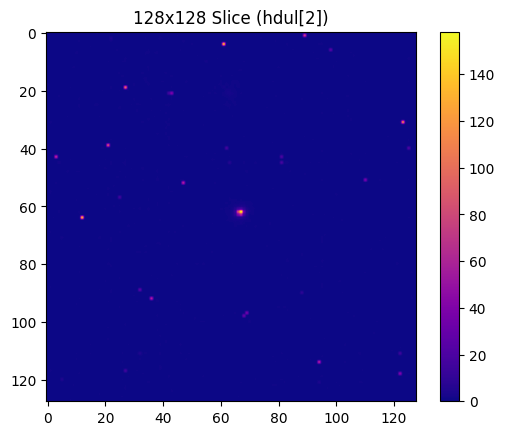

In [71]:
# Display hdul[2].data
plt.imshow(hdul[2].data[1, :, :], cmap='plasma', aspect='equal')
plt.colorbar()
plt.title("128x128 Slice (hdul[2])")
plt.show()

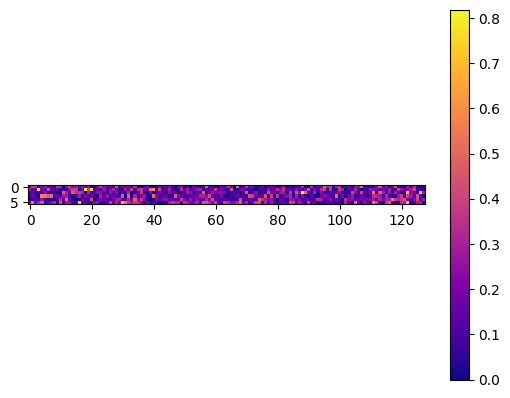

In [72]:
# Plot hdul[2].data
plt.imshow(hdul[2].data[:, :, 0], cmap='plasma')
plt.colorbar()
plt.show()

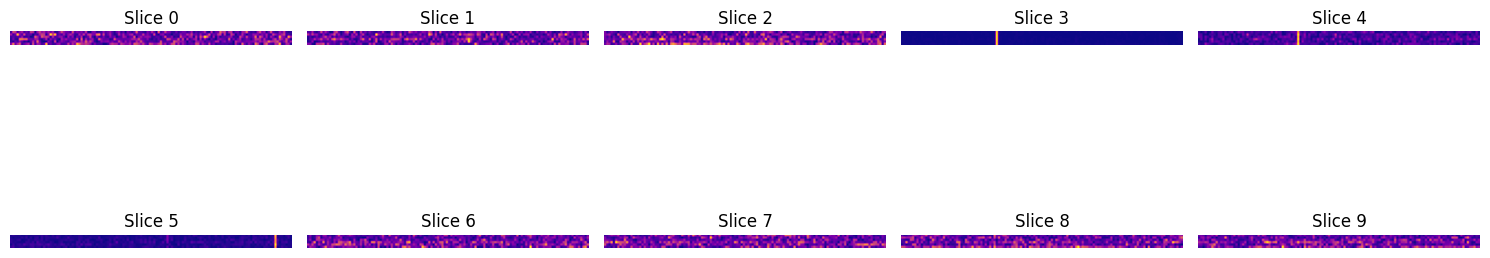

In [73]:
# Set up a 2x5 grid for displaying 10 slices
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Loop through the slices and plot each one in the grid
for i in range(10):
    ax = axes[i // 5, i % 5]  # Calculate the grid position
    ax.imshow(hdul[2].data[:, :, i], cmap='plasma')
    ax.set_title(f"Slice {i}")
    ax.axis('off')  # Hide axes for a cleaner look

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

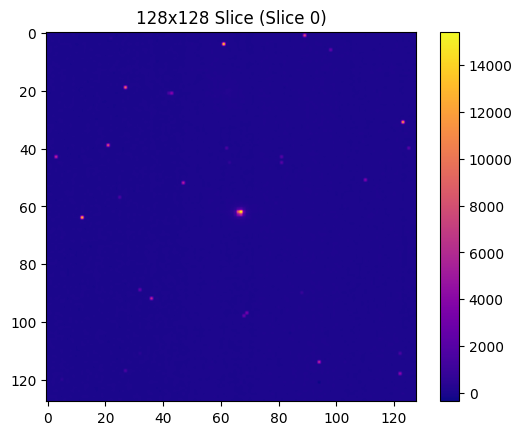

In [39]:
# Display hdul[1].data
plt.imshow(hdul[1].data[0, :, :], cmap='plasma', aspect='equal')  # Adjust the slice index as needed
plt.colorbar()
plt.title("128x128 Slice (Slice 0)")
plt.show()

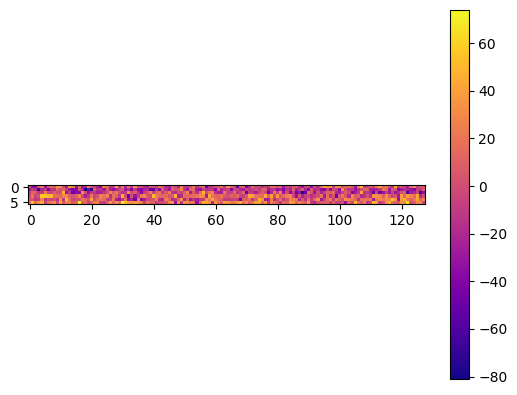

In [25]:
# Plot hdul[1].data
plt.imshow(hdul[1].data[:, :, 0], cmap='plasma')
plt.colorbar()
plt.show()

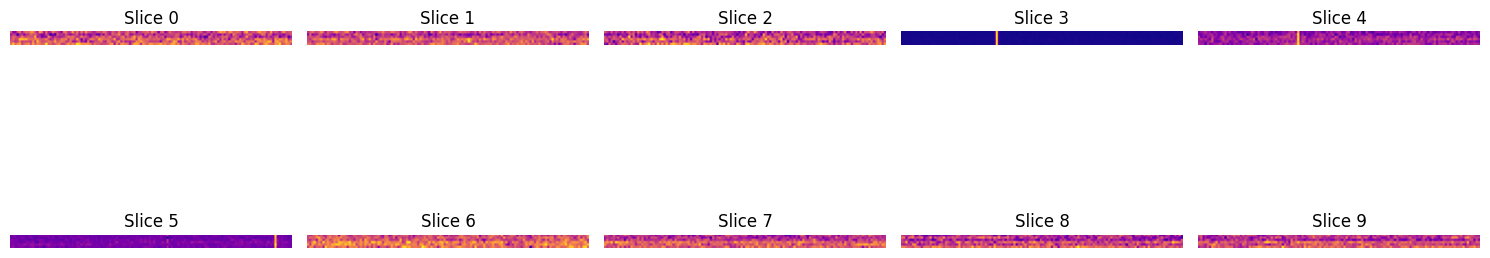

In [28]:
# Set up a 2x5 grid for displaying 10 slices
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Loop through the slices and plot each one in the grid
for i in range(10):
    ax = axes[i // 5, i % 5]  # Calculate the grid position
    ax.imshow(hdul[1].data[:, :, i], cmap='plasma')
    ax.set_title(f"Slice {i}")
    ax.axis('off')  # Hide axes for a cleaner look

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

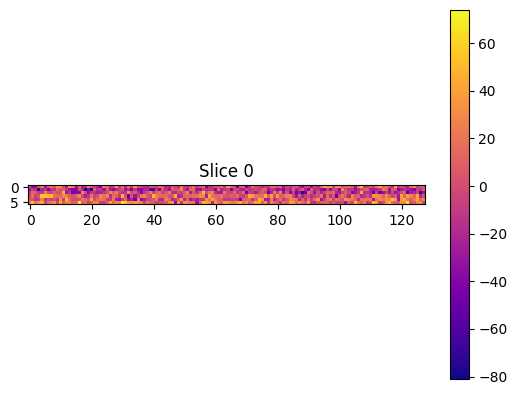

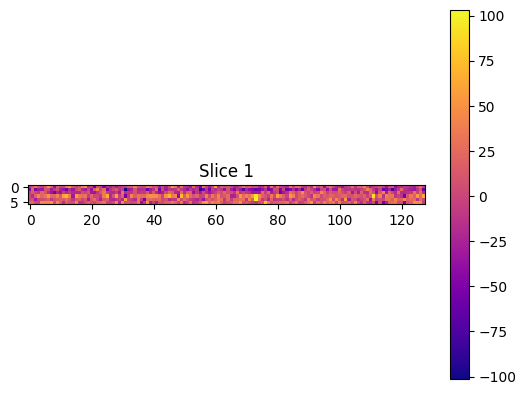

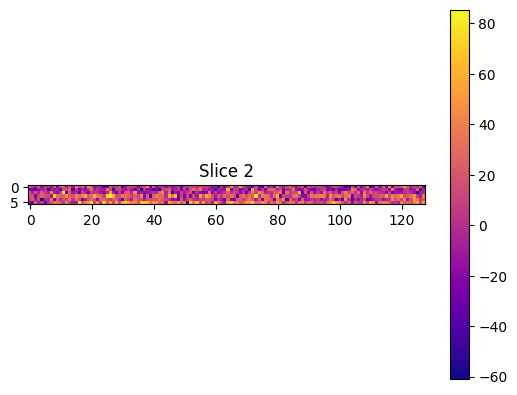

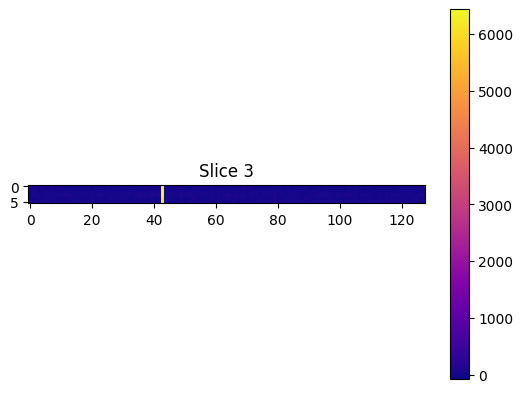

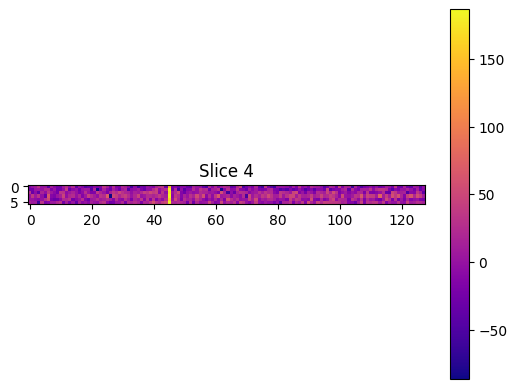

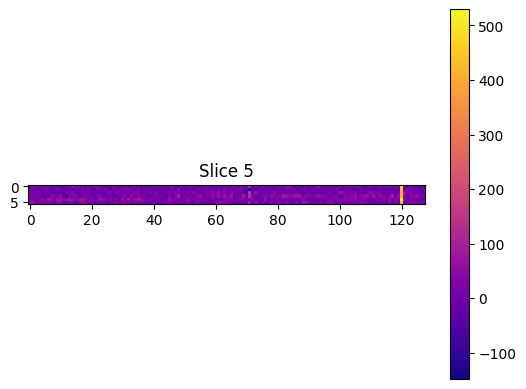

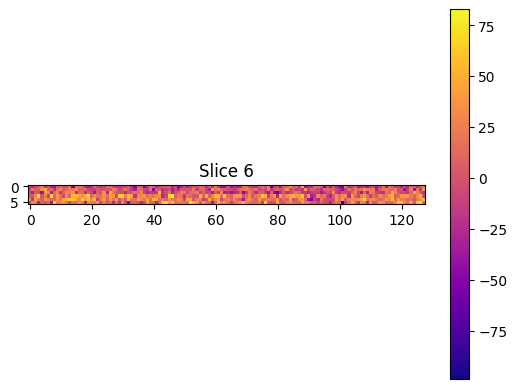

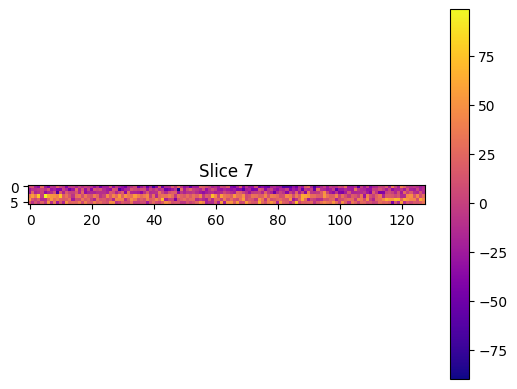

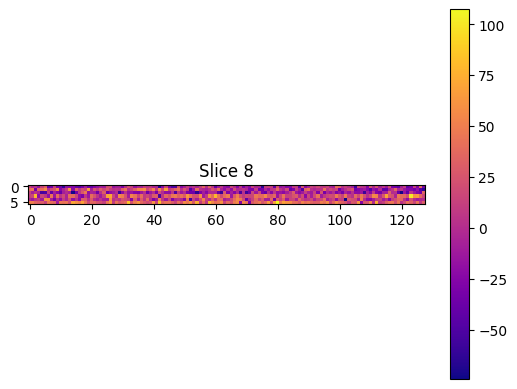

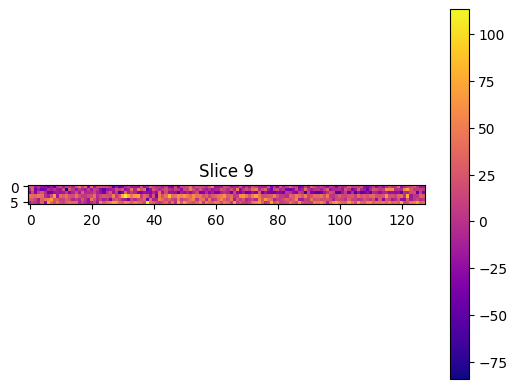

In [26]:
# Loop through a range of slices in the third dimension
for i in range(10):  # Adjust range as needed
    plt.imshow(hdul[1].data[:, :, i], cmap='plasma')
    plt.colorbar()
    plt.title(f"Slice {i}")
    plt.show()

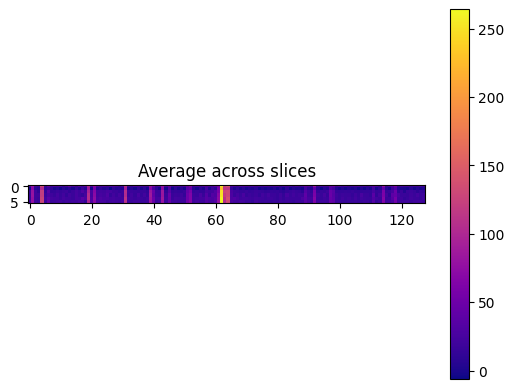

In [27]:
# Average of all slices in the third dimension
average_image = hdul[1].data.mean(axis=2)
plt.imshow(average_image, cmap='plasma')
plt.colorbar()
plt.title("Average across slices")
plt.show()

In [ ]:
# Close the FITS file when done
hdul.close()